In [1]:
# import python modules/libraries

import glob
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap

from warnings import filterwarnings
filterwarnings(action='ignore')


In [2]:
# load in no2 obs and model data files

curtain_files = sorted(glob.glob('Searey*curtain_mission*.nc'))
track_files = sorted(glob.glob('Searey*track_mission*.nc'))

for i in range(len(curtain_files)):
    print(curtain_files[i])

print('')

for i in range(len(track_files)):
    print(track_files[i])


Searey_20230802_R0_L1_curtain_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc
Searey_20230802_R0_L2_curtain_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc
Searey_20230802_R0_L3_curtain_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc

Searey_20230802_R0_L1_track_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc
Searey_20230802_R0_L2_track_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc
Searey_20230802_R0_L3_track_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc


In [3]:
# extract no2 data by searey flight leg
# print min/max of valid no2 data for each searey flight leg

obs_no2_all = []
mod_no2_all = []

obs_no2_l1 = []
mod_no2_l1 = []

obs_no2_l2 = []
mod_no2_l2 = []

obs_no2_l3 = []
mod_no2_l3 = []

for i in range(len(curtain_files)):
    dat_curtain = Dataset(curtain_files[i],'r')
    dat_track = Dataset(track_files[i],'r')

    obs_no2_track = dat_track.variables['no2_in_situ'][5*60:] # ppbv
    mod_no2_track = dat_track.variables['no2'][5*60:] # ppbv

    obs_utcsec_curtain = dat_curtain.variables['utcsec'][5*60:]/3600
    obs_no2_curtain = dat_curtain.variables['no2_in_situ'][5*60:]
    obs_alt_curtain = dat_curtain.variables['zco'][5*60:]
    
    mod_no2_curtain = (dat_curtain.variables['chem_curtain'][1,5*60:,:]).T
    mod_alt_curtain = (dat_curtain.variables['zcurt'][5*60:,:]).T
    
    mod_time_curtain = np.zeros(mod_no2_curtain.shape)
    mod_time_curtain[:,:] = np.nan
    
    for j in range(len(obs_utcsec_curtain)):
        mod_time_curtain[:,j] = obs_utcsec_curtain[j]

    for j in range(len(obs_no2_track)):
        obs_no2_all.append(obs_no2_track[j])

    for j in range(len(mod_no2_track)):
        mod_no2_all.append(mod_no2_track[j])

    if i == 0:

        for j in range(len(obs_no2_track)):
            obs_no2_l1.append(obs_no2_track[j])
    
        for j in range(len(mod_no2_track)):
            mod_no2_l1.append(mod_no2_track[j])

        obs_utcsec_curtain_l1 = obs_utcsec_curtain.copy()
        obs_alt_curtain_l1 = obs_alt_curtain.copy()
        obs_no2_curtain_l1 = obs_no2_curtain.copy()

        mod_time_curtain_l1 = mod_time_curtain.copy()
        mod_alt_curtain_l1 = mod_alt_curtain.copy()
        mod_no2_curtain_l1 = mod_no2_curtain.copy()
        
    if i == 1:

        for j in range(len(obs_no2_track)):
            obs_no2_l2.append(obs_no2_track[j])
    
        for j in range(len(mod_no2_track)):
            mod_no2_l2.append(mod_no2_track[j])

        obs_utcsec_curtain_l2 = obs_utcsec_curtain.copy()
        obs_alt_curtain_l2 = obs_alt_curtain.copy()
        obs_no2_curtain_l2 = obs_no2_curtain.copy()

        mod_time_curtain_l2 = mod_time_curtain.copy()
        mod_alt_curtain_l2 = mod_alt_curtain.copy()
        mod_no2_curtain_l2 = mod_no2_curtain.copy()

    if i == 2:

        for j in range(len(obs_no2_track)):
            obs_no2_l3.append(obs_no2_track[j])
    
        for j in range(len(mod_no2_track)):
            mod_no2_l3.append(mod_no2_track[j])
            
        obs_utcsec_curtain_l3 = obs_utcsec_curtain.copy()
        obs_alt_curtain_l3 = obs_alt_curtain.copy()
        obs_no2_curtain_l3 = obs_no2_curtain.copy()

        mod_time_curtain_l3 = mod_time_curtain.copy()
        mod_alt_curtain_l3 = mod_alt_curtain.copy()
        mod_no2_curtain_l3 = mod_no2_curtain.copy()

    print('Leg 0'+str(i+1))
    print('Obs (min,max):',np.nanmin(obs_no2_track),np.nanmax(obs_no2_track))
    print('Mod (min, max):',np.nanmin(mod_no2_track),np.nanmax(mod_no2_track))
    print('Number of valid data points',len(obs_no2_track))
    print('')


Leg 01
Obs (min,max): 0.0 10.46
Mod (min, max): 1.5004995 10.575962
Number of valid data points 5465

Leg 02
Obs (min,max): 0.0 2.45
Mod (min, max): 0.0 2.4632728
Number of valid data points 5572

Leg 03
Obs (min,max): 0.0 3.71
Mod (min, max): 0.0 4.86899
Number of valid data points 9402



In [4]:
# print searey flight leg times in CST

time_vars = [mod_time_curtain_l1,mod_time_curtain_l2,mod_time_curtain_l3]

for i in range(len(time_vars)):
    print('Leg 0'+str(i+1))
    print('start:',time_vars[i][0,:][0]-6,'CST')
    print('end:',time_vars[i][0,:][-1]-6,'CST')
    print('')


Leg 01
start: 9.144444465637207 CST
end: 10.746665954589844 CST

Leg 02
start: 11.788333892822266 CST
end: 13.397222518920898 CST

Leg 03
start: 14.178054809570312 CST
end: 16.901111602783203 CST



In [5]:
# create rainbow colorbar to match other figures in manuscript

def create_cmap_from_colorbar_image(image_path):
    """
    Creates a Matplotlib colormap from a color bar image.

    Args:
        image_path (str): The file path to the color bar image.

    Returns:
        matplotlib.colors.LinearSegmentedColormap: The custom colormap.
    """
    # 1. Load the image
    img = mpimg.imread(image_path)
    
    # 2. Extract the relevant pixel data
    # Assuming a vertical color bar, we take the first column of pixels (index 0)
    # and all rows. The last dimension [:] gets the R, G, B, A values.
    # Adjust the column index (e.g., to a middle column if the first has a border) 
    # if necessary.
    colors_from_img = img[:, 0, :]
    
    # The number of entries in the colormap should match the number of pixels in 
    # the color bar image (the height of the image).
    N = img.shape[0]
    
    # 3. Create the LinearSegmentedColormap
    # The 'colors_from_img' is a list of colors which is used to define the map.
    custom_cmap = LinearSegmentedColormap.from_list('custom_colorbar', colors_from_img, N=N)
    
    return custom_cmap

# --- Usage Example ---
# Replace 'path/to/your/colorbar_image.png' with the actual path to your image file
image_path = 'Laura.Rainbow.Colorbar.png' 

try:
    my_cmap = create_cmap_from_colorbar_image(image_path)
    
    # 4. Use the new colormap
    # Example: Display some random data using the custom colormap
    #data = np.random.rand(10, 10)
    #plt.imshow(data, cmap=my_cmap)
    #plt.colorbar()
    #plt.title("Plot using custom colormap from image")
    #plt.show()

except FileNotFoundError:
    print(f"Error: Image file not found at {image_path}")
    print("Please update the 'image_path' variable to your image's location.")


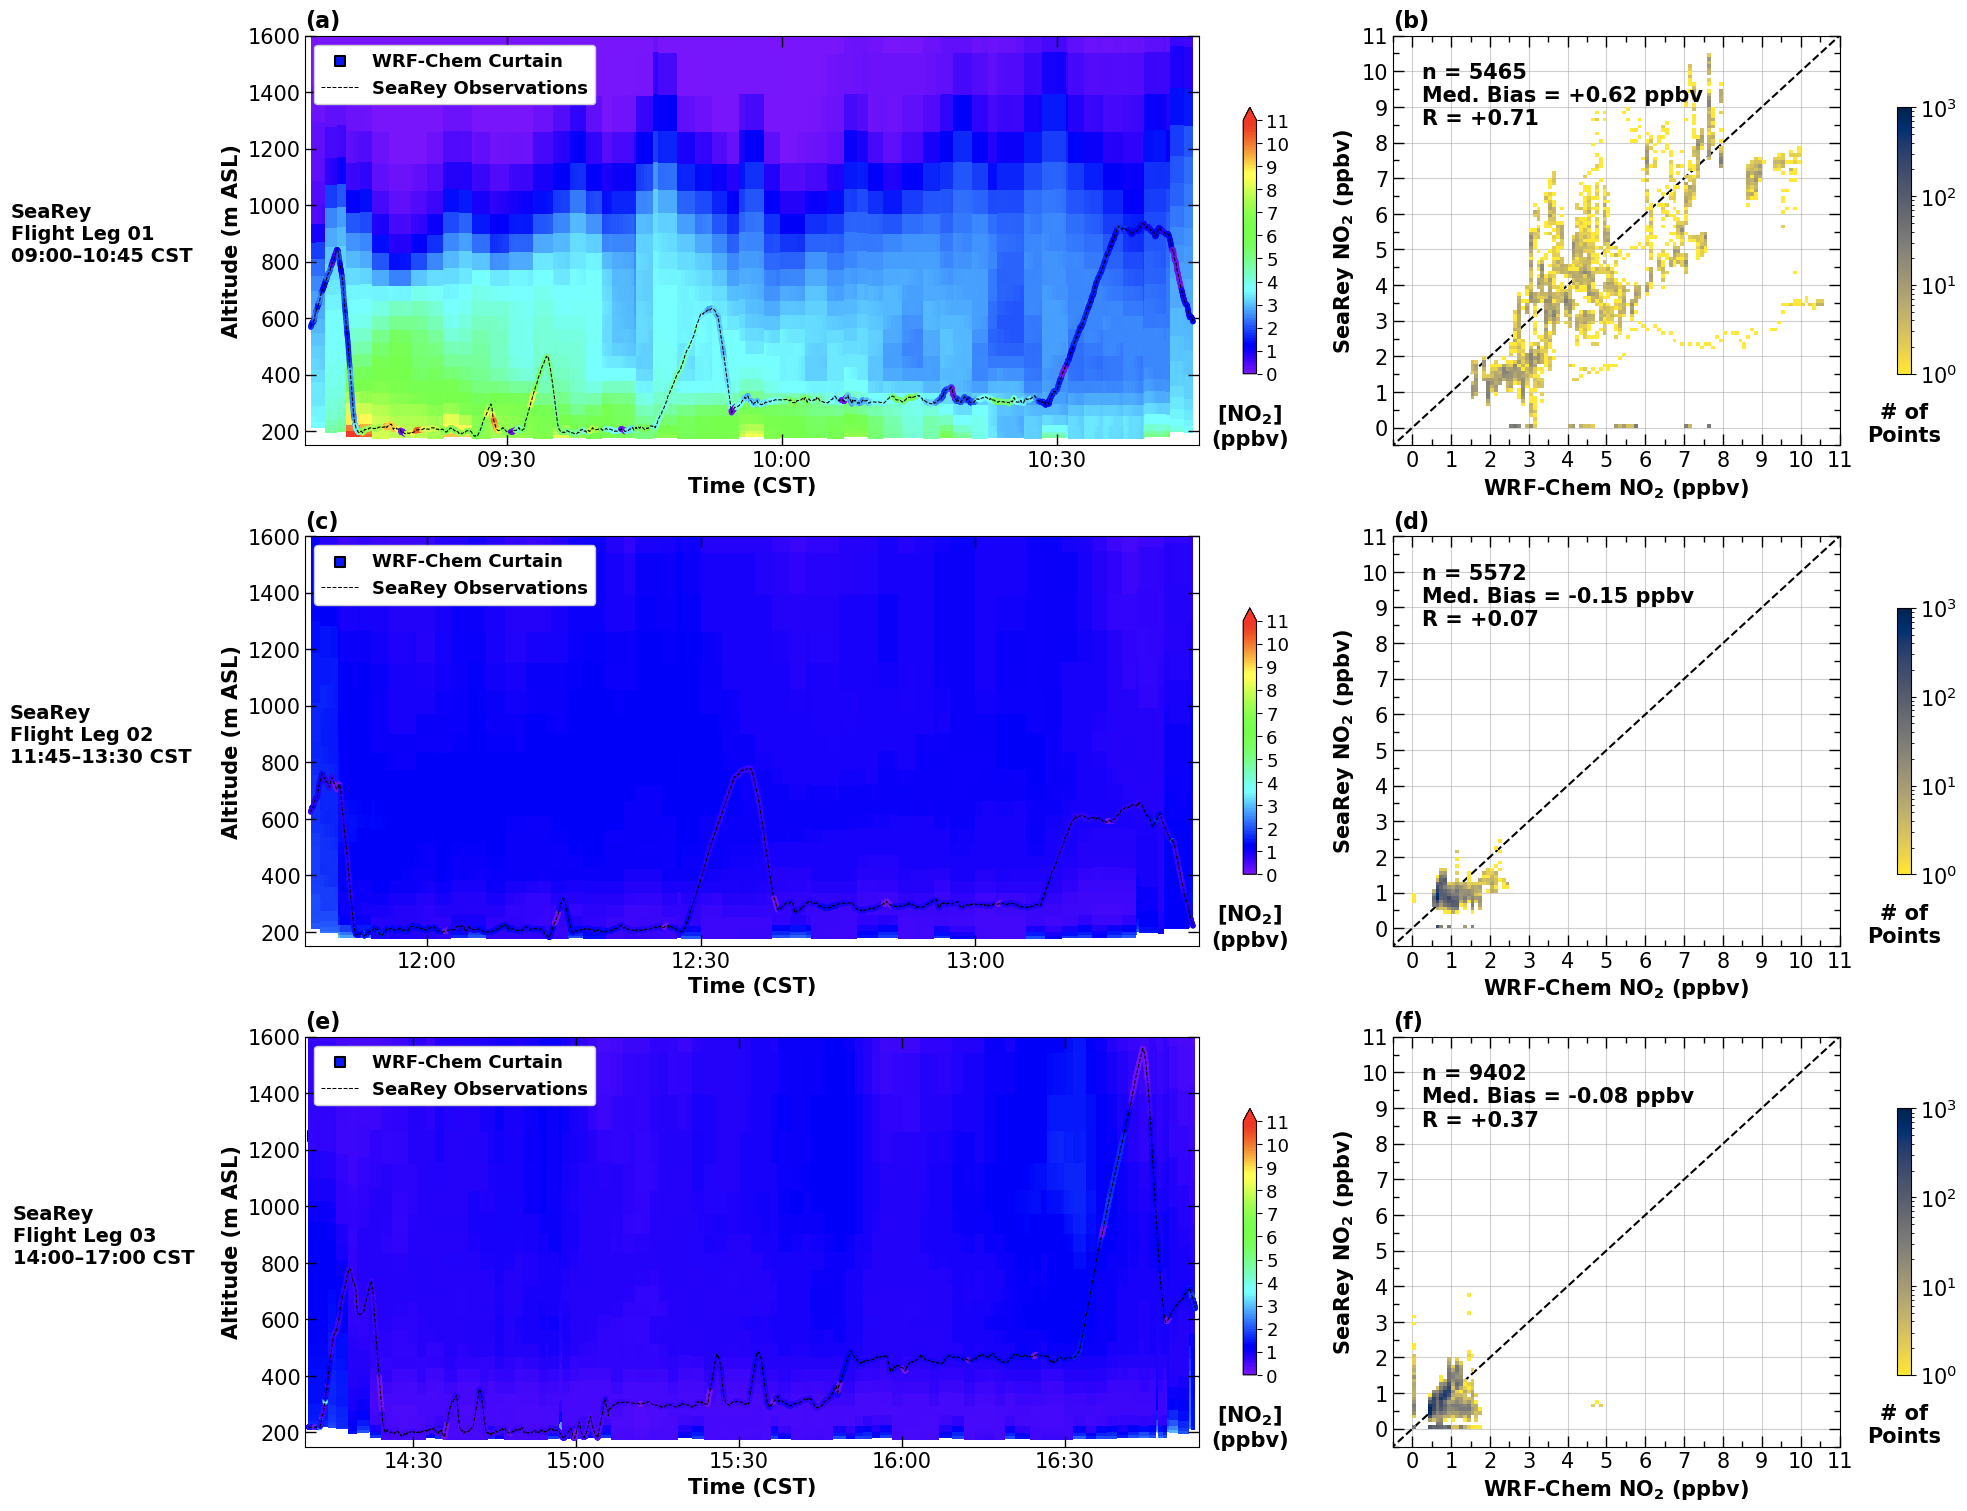

In [6]:
# produce Figure 10 for AGES+ Chicago manuscript

fig = plt.figure(figsize=(20, 15),constrained_layout=True)
gs = fig.add_gridspec(3,3)

i = 0
row_idx = [0,0,1,1,2,2]

flight_leg = ['01','01','02','02','03']
flight_leg_x = [14.70,[],17.34,[],19.37]
leg_times = ['09:00–10:45 CST',[],'11:45–13:30 CST',[],'14:00–17:00 CST',[]]

# scatter data and plotting specifics
scatter_x_mod = [[],mod_no2_l1,[],mod_no2_l2,[],mod_no2_l3]
scatter_y_obs = [[],obs_no2_l1,[],obs_no2_l2,[],obs_no2_l3]
scatter_bins = [[],110,[],110,[],110]
scatter_range_max = [[],11,[],11,[],11]
norm_vmax = [[],1000,[],1000,[],1000]
scatter_text_x = [[],0.5,[],0.5,[],0.5]
scatter_text_y = [[],10,[],10,[],10]

# curtain data and plotting specifics
curtain_x_mod = [mod_time_curtain_l1,[],mod_time_curtain_l2,[],mod_time_curtain_l3,[]]
curtain_y_mod = [mod_alt_curtain_l1,[],mod_alt_curtain_l2,[],mod_alt_curtain_l3,[]]
curtain_c_mod = [mod_no2_curtain_l1,[],mod_no2_curtain_l2,[],mod_no2_curtain_l3,[]]

curtain_x_obs = [obs_utcsec_curtain_l1,[],obs_utcsec_curtain_l2,[],obs_utcsec_curtain_l3,[]]
curtain_y_obs = [obs_alt_curtain_l1,[],obs_alt_curtain_l2,[],obs_alt_curtain_l3,[]]
curtain_c_obs = [obs_no2_curtain_l1,[],obs_no2_curtain_l2,[],obs_no2_curtain_l3,[]]
curtain_vmax = [11,[],11,[],11,[]]
curtain_ymax = [1600,[],1600,[],1600,[]]

curtain_xticks = [[15.5,16.0,16.5],[],[18.0,18.5,19.0],[],[20.5,21.0,21.5,22.0,22.5],[]]
curtain_xtick_labels = [['09:30','10:00','10:30'],[],['12:00','12:30','13:00'],[],['14:30','15:00','15:30','16:00','16:30'],[]]

plot_titles = ['(a)','(b)','(c)','(d)','(e)','(f)'] # across rows

nmb_vals = [[],'+16.0 %',[],'-2.7 %',[],'-2.4 %']
medbias_vals = [[],'+0.62 ppbv',[],'-0.15 ppbv',[],'-0.08 ppbv']
r_vals = [[],'+0.71',[],'+0.07',[],'+0.37']
r2_vals = [[],'0.50',[],'0.01',[],'0.14']

for i in range(6):

    # plot curtain plots
    if i in [0,2,4]:
        
        ax = fig.add_subplot(gs[row_idx[i],0:2])

        # wrf-chem curtain
        b = ax.pcolormesh(curtain_x_mod[i],curtain_y_mod[i],curtain_c_mod[i],cmap=my_cmap,vmin=0,vmax=curtain_vmax[i],zorder=0)
        # plotting example point from wrf-chem curtain for legend label
        ax.scatter(curtain_x_mod[i][20,50],curtain_y_mod[i][20,50],c=1.5,s=50,
                   marker='s',cmap=my_cmap,vmin=0,vmax=curtain_vmax[i],zorder=-5,label='WRF-Chem Curtain',
                   edgecolors='k',linewidths=1.5)
        # plotting searey obs as scatter points
        ax.scatter(curtain_x_obs[i],curtain_y_obs[i],c=curtain_c_obs[i],s=8,cmap=my_cmap,vmin=0,vmax=curtain_vmax[i],zorder=9)
        # plotting dashed line along searey obs for easier identification and for legend label
        ax.plot(curtain_x_obs[i],curtain_y_obs[i],c='k',linestyle='dashed',linewidth=0.75,label='SeaRey Observations',zorder=10)
        ax.set_ylim([150,curtain_ymax[i]])
        ax.set_xlim([np.min(curtain_x_obs[i])-0.01,np.max(curtain_x_obs[i])+0.01])

        c = plt.colorbar(b,shrink=0.65,pad=0.05,extend='max')
        tick_positions = [0,1,2,3,4,5,6,7,8,9,10,11]
        tick_labels = ['0','1','2','3','4','5','6','7','8','9','10','11']
        c.set_ticks(tick_positions)
        c.set_ticklabels(tick_labels)
        c.ax.set_xlabel('\n'+r'[NO$_{\rm \bf{2}}$]'+'\n(ppbv)',fontsize=15,fontweight='bold')
        c.ax.tick_params(labelsize=13)

        ax.set_xticks(curtain_xticks[i],curtain_xtick_labels[i])
        ax.tick_params(which='both', width=1,top=True,right=True,bottom=True,direction='in')
        ax.tick_params(which='major', length=8,top=True,right=True,bottom=True,direction='in',labelsize=15)
        ax.tick_params(which='minor', length=4, color='k',top=True,right=True,direction='in')

        ax.set_xlabel('Time (CST)',fontsize=15,fontweight='bold')
        ax.set_ylabel('Altitude (m ASL)',fontsize=15,fontweight='bold')
        ax.set_title(plot_titles[i],loc='left',fontweight='bold',fontsize=16)
        ax.legend(loc='upper left',framealpha=1.0,prop={'weight':'bold','size':13})

        ax.text(flight_leg_x[i]-0.1,curtain_ymax[i]/2,'SeaRey\nFlight Leg '+flight_leg[i]+'\n'+leg_times[i],fontweight='bold',fontsize=14)

    # plot scatter plots
    if i in [1,3,5]:
        
        ax = fig.add_subplot(gs[row_idx[i],2])
        
        b = ax.hist2d(scatter_x_mod[i],scatter_y_obs[i],bins=scatter_bins[i],
                      range=[[0,scatter_range_max[i]],[0,scatter_range_max[i]]],
                      cmin=1,cmap='cividis_r',norm=colors.LogNorm(vmin=1,vmax=norm_vmax[i]),zorder=10)

        c = plt.colorbar(b[3],shrink=0.65,pad=0.1)
        c.ax.set_xlabel('\n# of\nPoints',fontsize=15,fontweight='bold')
        c.ax.tick_params(labelsize=15)

        ax.text(scatter_text_x[i]-0.25,scatter_text_y[i]-1.5,'n = '+str(len(scatter_x_mod[i]))+'\nMed. Bias = '+medbias_vals[i]+'\nR = '+r_vals[i],fontsize=15,fontweight='bold',zorder=500)
        
        ax.plot([-1,scatter_range_max[i]+1],[-1,scatter_range_max[i]+1],c='k',linestyle='dashed',zorder=9)
        ax.set_xlim([-0.5,scatter_range_max[i]])
        ax.set_ylim([-0.5,scatter_range_max[i]])

        ax.set_xlabel(r'WRF-Chem NO$_{\rm \bf{2}}$ (ppbv)',fontsize=15,fontweight='bold')
        ax.set_ylabel('\n'+r'SeaRey NO$_{\rm \bf{2}}$ (ppbv)',fontsize=15,fontweight='bold')
        ax.set_title(plot_titles[i],loc='left',fontweight='bold',fontsize=16)

        ax.xaxis.set_major_locator(MultipleLocator())
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_major_locator(MultipleLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(which='both', width=1,top=True,right=True,bottom=True,direction='in')
        ax.tick_params(which='major', length=8,top=True,right=True,bottom=True,direction='in',labelsize=15)
        ax.tick_params(which='minor', length=4, color='k',top=True,right=True,direction='in')

        ax.grid(alpha=0.6)

plt.show()
